# Exercise 18: Principal component methods

This homework assignment is designed to give you an intuition on principal component approaches to understanding high dimensional statistical relationships.

Like earlier homework, you will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading data (1 point)

We are going to look for low dimensional relationships between brain volume measures and working memory capacity.

First, we will need to load the `pls`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [29]:
# install.packages('pls')
libraries <- c('pls', 'tidyverse', 'ggplot2')
lapply(libraries, library, character.only = T)

[[1]]
 [1] "reshape2"  "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"    
 [7] "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse" "pls"      
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[2]]
 [1] "reshape2"  "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"    
 [7] "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse" "pls"      
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[3]]
 [1] "reshape2"  "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"    
 [7] "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse" "pls"      
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"

Use `read.csv` function to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file in the **hcp_data** folder.

(a) Using the tidyverse tools, make a new dataframe `d1` that only includes the Flanker Task performance (`Flanker_Unadj`) and *all* freesurfer **volume** measures for the right and left hemispheres together. Remove both "na's" and any columns that consist of only zeros.

Hint: Look up using the `ends_with` function to only select variables that end with "_Vol"

Use the `head` function to look at the first few rows of each data frame.

In [30]:
df <- read.csv('/Users/kaitlyndalbon/Desktop/Carnegie_Mellon/Courses/85732_Data_Science/DataSciencePsychNeuro/Exercise datasets/hcp_data/unrestricted_trimmed_1_7_2020_10_50_44.csv')
d1 <- df %>% select(c('Flanker_Unadj', ends_with('_Vol'))) %>% drop_na() %>% select(where(~ !any(. == 0, na.rm = TRUE)))
head(d1)

,Flanker_Unadj,FS_IntraCranial_Vol,FS_BrainSeg_Vol,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,FS_SubCort_GM_Vol,FS_Total_GM_Vol,FS_SupraTentorial_Vol,FS_L_WM_Vol,⋯,FS_R_VentDC_Vol,FS_R_Vessel_Vol,FS_R_ChoroidPlexus_Vol,FS_WM_Hypointens_Vol,FS_OpticChiasm_Vol,FS_CC_Posterior_Vol,FS_CC_MidPosterior_Vol,FS_CC_Central_Vol,FS_CC_MidAnterior_Vol,FS_CC_Anterior_Vol
,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,130.42,1864518,1406924,304488,305634,610122,70240,807245,1239692,269963,⋯,4933,80,1613,1269,325,800,409,569,522,813
2,112.56,1512540,1109710,240030,243207,483238,56623,664124,957615,203472,⋯,3816,70,1007,1155,195,1029,526,578,576,649
3,121.18,1684117,1280171,260695,265243,525938,63869,726206,1106881,247504,⋯,5074,88,1303,1279,302,972,589,528,471,858
4,126.53,1816044,1321362,276506,278002,554508,74869,762308,1155067,254742,⋯,5462,81,909,1154,296,1065,618,838,729,1072
5,101.85,1437868,1053766,203718,210539,414257,58813,579632,916973,213012,⋯,4529,75,1215,377,235,1057,591,538,430,849
6,107.04,1512727,1126655,242489,248807,491296,62092,665024,984952,205342,⋯,3730,93,1331,554,258,1033,494,487,489,992


---
## 2. Correlational structure (4 points)

(a) Take a look at the correlation between all of the freesurfer volume measures ("FS_") using the `cor` function. Create a new variable called `fs_cor` that is the correlation matrix for only the freesurfer volumes

In [31]:
fs_cor <- d1 %>% select(starts_with('FS')) %>% cor()
head(fs_cor)

,FS_IntraCranial_Vol,FS_BrainSeg_Vol,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,FS_SubCort_GM_Vol,FS_Total_GM_Vol,FS_SupraTentorial_Vol,FS_L_WM_Vol,FS_R_WM_Vol,⋯,FS_R_VentDC_Vol,FS_R_Vessel_Vol,FS_R_ChoroidPlexus_Vol,FS_WM_Hypointens_Vol,FS_OpticChiasm_Vol,FS_CC_Posterior_Vol,FS_CC_MidPosterior_Vol,FS_CC_Central_Vol,FS_CC_MidAnterior_Vol,FS_CC_Anterior_Vol
FS_IntraCranial_Vol,1.0000000,0.8977578,0.8400174,0.8439151,0.8452780,0.7885140,0.8751297,0.8851581,0.8311086,0.8278063,⋯,0.6924556,0.1536332,0.4286121,0.2225826,0.3309762,0.3448680,0.1896089,0.1973414,0.2845997,0.4018212
FS_BrainSeg_Vol,0.8977578,1.0000000,0.9448159,0.9482717,0.9502618,0.8689939,0.9664839,0.9958421,0.9502506,0.9482723,⋯,0.7506456,0.2067837,0.4125810,0.3231443,0.3500672,0.3767737,0.2724347,0.2707686,0.3534842,0.4308723
FS_LCort_GM_Vol,0.8400174,0.9448159,1.0000000,0.9844592,0.9960196,0.7897863,0.9821287,0.9485617,0.8282356,0.8220444,⋯,0.6310310,0.1700152,0.3516475,0.3272222,0.2735485,0.2515157,0.1961809,0.2089434,0.2572979,0.3140626
FS_RCort_GM_Vol,0.8439151,0.9482717,0.9844592,1.0000000,0.9961939,0.7925724,0.9830322,0.9518674,0.8330846,0.8307516,⋯,0.6320048,0.1759543,0.3441177,0.3390336,0.2834184,0.2444868,0.1918267,0.2118854,0.2590016,0.3054070
FS_TotCort_GM_Vol,0.8452780,0.9502618,0.9960196,0.9961939,1.0000000,0.7942866,0.9864250,0.9539460,0.8339331,0.8296759,⋯,0.6339909,0.1736941,0.3491995,0.3344959,0.2796276,0.2489306,0.1947377,0.2112533,0.2591679,0.3108966
FS_SubCort_GM_Vol,0.7885140,0.8689939,0.7897863,0.7925724,0.7942866,1.0000000,0.8407289,0.8591265,0.8248311,0.8250502,⋯,0.8659743,0.2308144,0.3810439,0.2779295,0.3280826,0.3636716,0.3169406,0.2701718,0.3320954,0.4041212


(b) Load (and install locally if needed) the `reshape2` library in order to use the `melt` function on the new `fs_cor` object. Use `head` to show the new, melted `fs_cor` object.

In [32]:
# install.packages('reshape2')
library(reshape2)
fs_cor <- melt(fs_cor)
head(fs_cor)

,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,FS_IntraCranial_Vol,FS_IntraCranial_Vol,1.0000000
2,FS_BrainSeg_Vol,FS_IntraCranial_Vol,0.8977578
3,FS_LCort_GM_Vol,FS_IntraCranial_Vol,0.8400174
4,FS_RCort_GM_Vol,FS_IntraCranial_Vol,0.8439151
5,FS_TotCort_GM_Vol,FS_IntraCranial_Vol,0.8452780
6,FS_SubCort_GM_Vol,FS_IntraCranial_Vol,0.7885140


Plot the correlation as a heatmap using `ggplot2`.

Hint: use the `scale_fill_gradient2` function to scale the colors between red and blue, capping the values at -1 and +1.

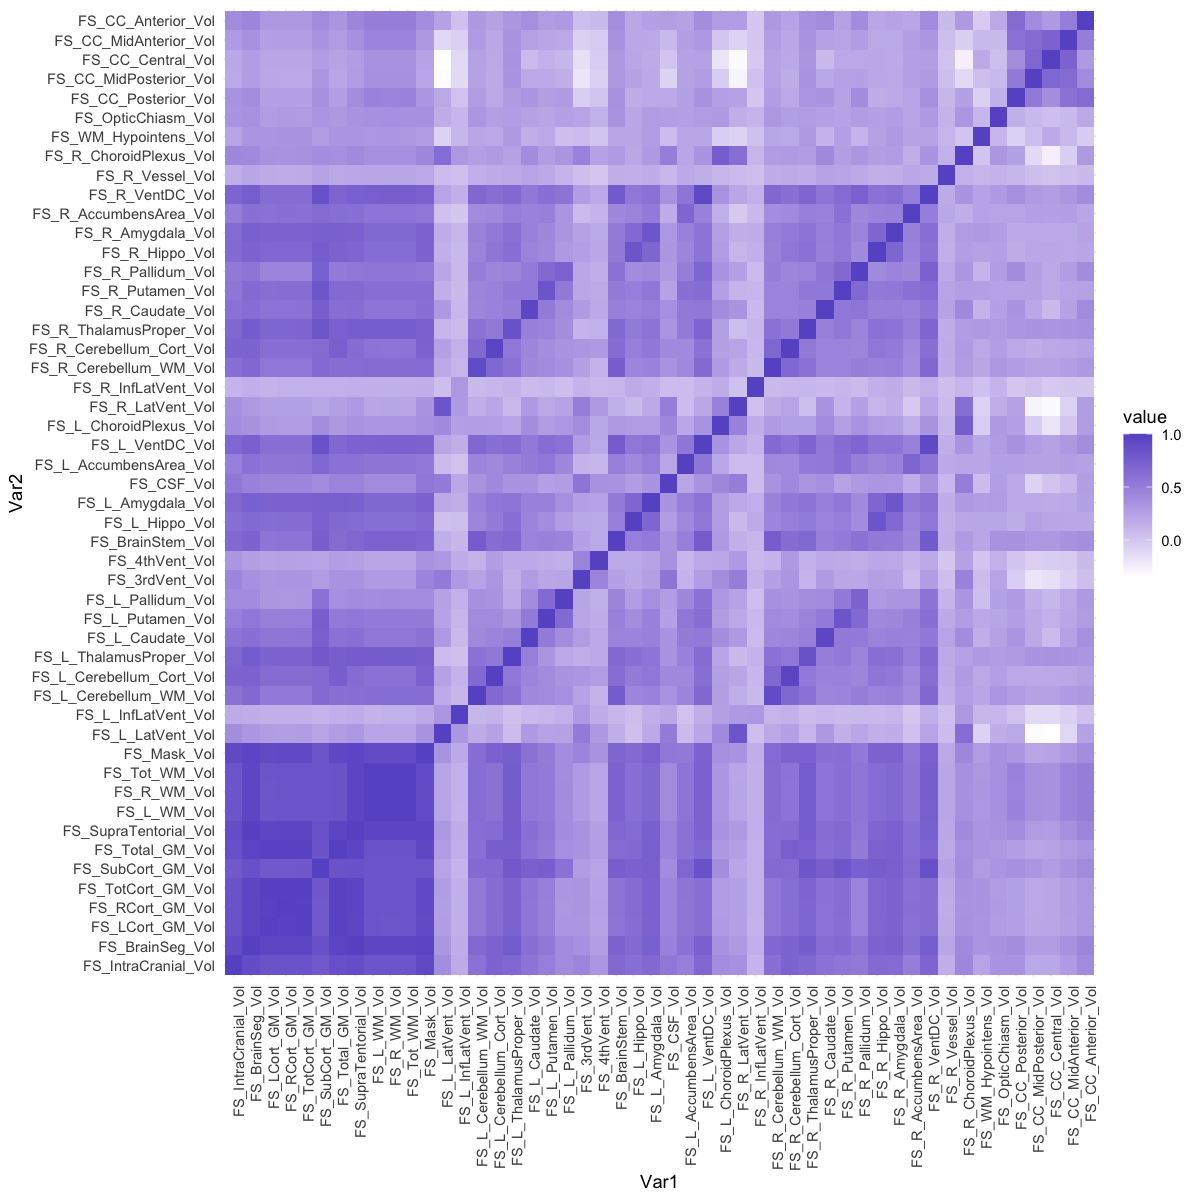

In [33]:
options(repr.plot.width = 10, repr.plot.height = 10)
ggplot(fs_cor, aes(x = Var1, y = Var2, fill = value)) +
geom_tile() +
scale_fill_gradient(low = "white", high = "slateblue") +
theme_minimal() +
theme(axis.text.x = element_text(angle = 90, hjust = 1))

What patterns do you see in the correlations?

> In the correlations, I'm noticing a positive correlation, and clustering of parts of the brain together. For example, in the bottom left quadrant, the grey matter variables correlate highly with each other. 


---
## 3. Principal component analysis (3 points)

Let's see how many principal components explain at *at least* 95% of the data.

(a) Create a new object called `fs_d.pca` using the `princomp` function (do not forget to scale the data).


In [34]:
fs_d.pca <- prcomp(d1, scale = T)
fs_d.pca

Standard deviations (1, .., p=51):
 [1] 4.828957e+00 2.071786e+00 1.643700e+00 1.445097e+00 1.301118e+00
 [6] 1.150550e+00 1.091108e+00 1.056871e+00 1.000491e+00 9.847124e-01
[11] 9.657736e-01 9.053543e-01 9.005132e-01 8.657464e-01 8.050780e-01
[16] 7.881471e-01 7.520487e-01 7.429686e-01 7.170114e-01 6.747316e-01
[21] 6.469724e-01 6.418947e-01 6.153194e-01 5.738427e-01 5.623753e-01
[26] 5.583713e-01 5.401354e-01 5.140939e-01 4.859813e-01 4.702604e-01
[31] 4.564397e-01 4.403459e-01 4.130301e-01 3.908985e-01 3.713577e-01
[36] 3.519774e-01 3.365476e-01 3.025506e-01 2.696148e-01 2.541633e-01
[41] 2.143803e-01 1.781651e-01 1.728627e-01 1.200019e-01 4.734447e-02
[46] 3.460008e-02 4.676302e-03 3.615813e-03 3.322479e-03 7.558130e-06
[51] 6.993531e-06

Rotation (n x k) = (51 x 51):
                                 PC1           PC2          PC3          PC4
Flanker_Unadj            -0.03888222  0.0213358829  0.020873444 -0.081282916
FS_IntraCranial_Vol      -0.18467440  0.0609387236  0.04662205

(b) Calculate the cumulative variance explained (not unique variance explained as in the tutorial) across the principal components and plot the results using `ggplot`.

List of 5
 $ sdev    : num [1:51] 4.83 2.07 1.64 1.45 1.3 ...
 $ rotation: num [1:51, 1:51] -0.0389 -0.1847 -0.2007 -0.1839 -0.1846 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:51] "Flanker_Unadj" "FS_IntraCranial_Vol" "FS_BrainSeg_Vol" "FS_LCort_GM_Vol" ...
  .. ..$ : chr [1:51] "PC1" "PC2" "PC3" "PC4" ...
 $ center  : Named num [1:51] 112 1579064 1179503 252281 257739 ...
  ..- attr(*, "names")= chr [1:51] "Flanker_Unadj" "FS_IntraCranial_Vol" "FS_BrainSeg_Vol" "FS_LCort_GM_Vol" ...
 $ scale   : Named num [1:51] 10.1 190246.3 123547 26773.3 27378.4 ...
  ..- attr(*, "names")= chr [1:51] "Flanker_Unadj" "FS_IntraCranial_Vol" "FS_BrainSeg_Vol" "FS_LCort_GM_Vol" ...
 $ x       : num [1:1113, 1:51] -8.71 3.2 -3.88 -8.98 2.94 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:51] "PC1" "PC2" "PC3" "PC4" ...
 - attr(*, "class")= chr "prcomp"


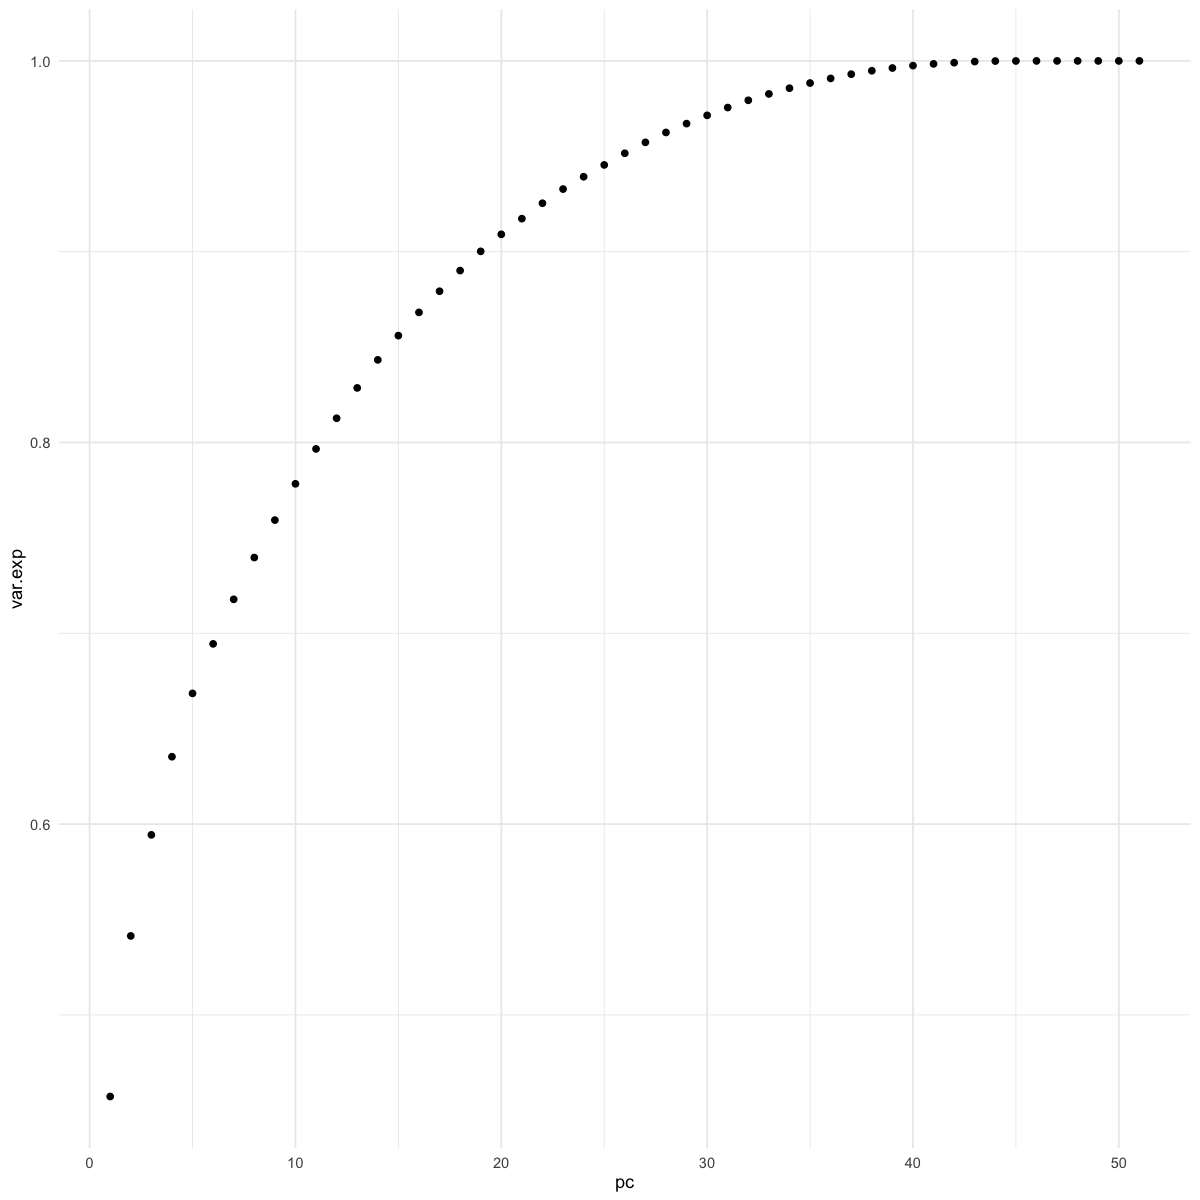

In [36]:
str(fs_d.pca)
cummu_var <- cumsum(fs_d.pca$sdev^2 / sum(fs_d.pca$sdev^2))
ggplot(data.frame(pc = 1:51, var.exp = cummu_var), aes(x=pc, y=var.exp)) + 
geom_point() + 
theme_minimal()

(c) Determine exactly how many principal components explain at least 95% of the variance.

Hint: Look up the `which` function.

In [37]:
str(which(cummu_var >= 0.95))
# This tells me that 26 principal components explain at least 95% of the variance.

 int [1:26] 26 27 28 29 30 31 32 33 34 35 ...


What does this tell you about the underlying dimensionality of the brain volume measures?

>  This tells me that the dimensionality of the brain volume is complex, therefore requiring a large number of components to account for 95% of the variance.

---
## 4. Associating with Flanker task peformance (4 points)

Now apply PCR to the `d1` object you created at the beginning (which includes the Flanker task scores) to find how freesurfer volumes predict Flanker task performance. Set the random seed to "2". Use cross-validation as the validation type and don't forget to scale your data. Show the `summary` of the model fit.

Hint: If you receive an error applying the "scale=TRUE" flag, then you likely still have columns of all zeros somewhere in your data table.

In [38]:
set.seed(2)
fit_pca <- pcr(Flanker_Unadj~., data = d1, scale = T, validation = "CV")
summary(fit_pca)

Data: 	X dimension: 1113 50 
	Y dimension: 1113 1
Fit method: svdpc
Number of components considered: 50

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           10.08    9.924    9.922    9.934    9.924    9.925    9.905
adjCV        10.08    9.923    9.921    9.932    9.921    9.922    9.901
       7 comps  8 comps  9 comps  10 comps  11 comps  12 comps  13 comps
CV       9.897    9.899    9.901     9.919     9.921     9.921     9.928
adjCV    9.894    9.896    9.898     9.915     9.911     9.914     9.921
       14 comps  15 comps  16 comps  17 comps  18 comps  19 comps  20 comps
CV        9.933     9.937     9.916     9.892     9.900     9.909     9.919
adjCV     9.927     9.936     9.899     9.883     9.891     9.899     9.908
       21 comps  22 comps  23 comps  24 comps  25 comps  26 comps  27 comps
CV        9.929     9.944     9.955     9.961     9.967     9.983     9.995
adjCV     9.918  

(b) Use the `validationplot` function to evaluate the bias-variance tradeoff using the cross-validated mean squared-error for each component.

NULL

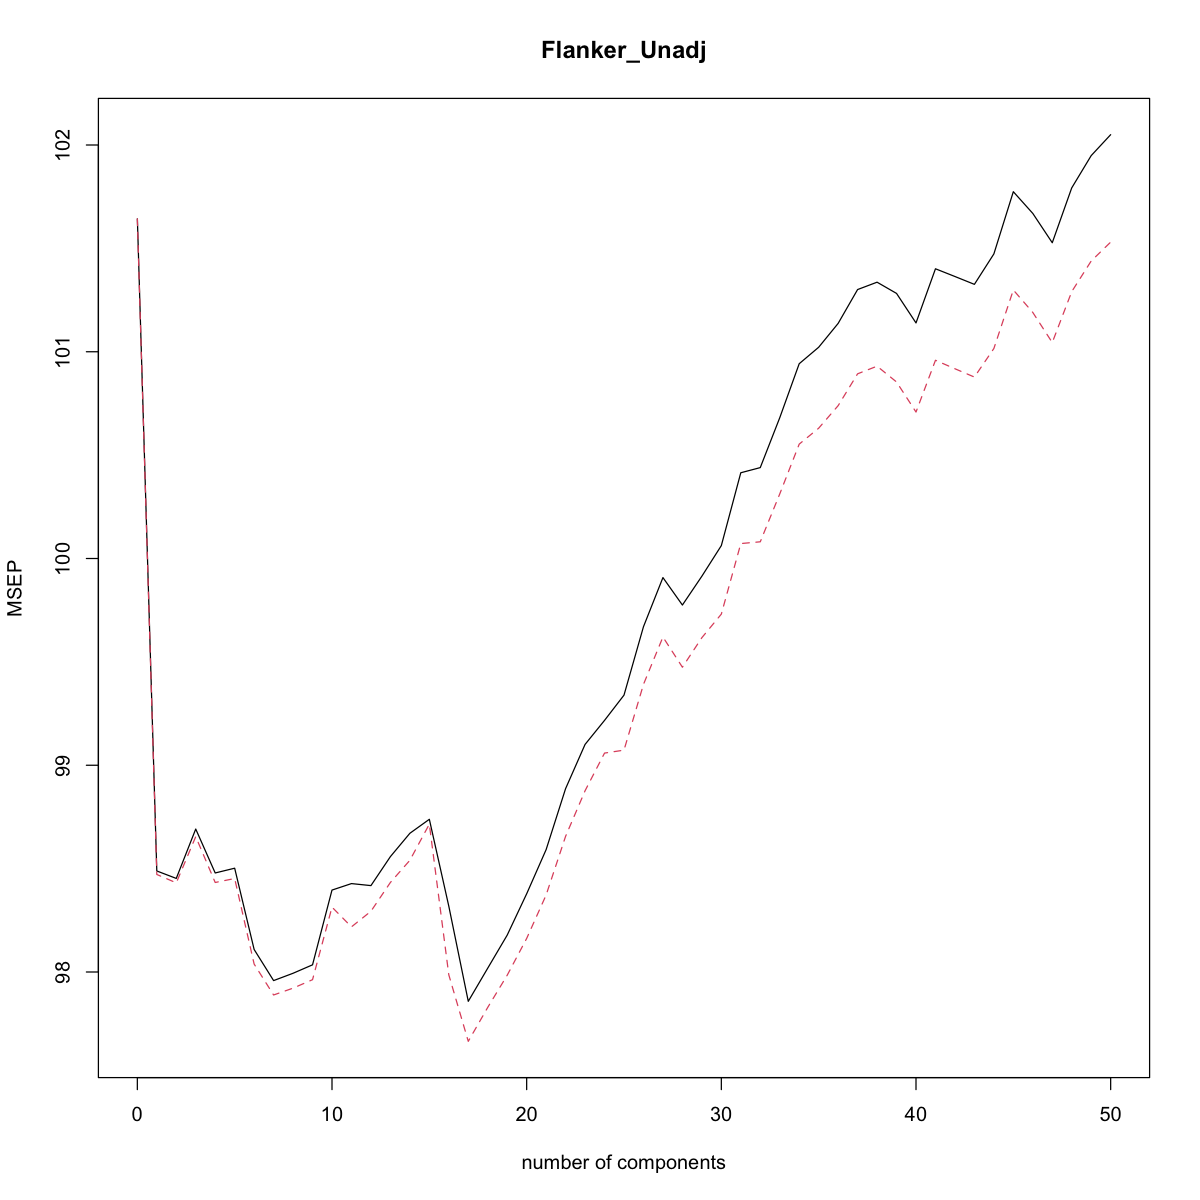

In [39]:
sigh <- validationplot(fit_pca,val.type="MSEP")
sigh

(c) Extract the MSEP values of the cross validated fit ("CV" not "adj_CV") from the model object using the `MSEP` funtion. Create a new array of these values. Use the `drop` function to remove the singleton dimension (the original array is 2x1x53 and we want a 2x53 object). Find the minimum value of the first row (the "CV").

In [40]:
msep_values <- MSEP(fit_pca, estimate = "CV")$val
msep_values <- drop(msep_values)
msep_values[1]

(Intercept) 
   101.6424

What what does this plot tell you about how many components best explain variance in Flanker task performance?

> This plot indicates that the best number of components is between 15 and 20, where MSEP drops the lowest. MSEP rapidly climbs past p=20, and fluctuates between 0 and 15. 

---
## 5. Reflection (2 points)

Compare the number of components that explain variance in X alone (the brain volumes) to the number of components that explain performance in the Flanker task. What does the difference in these two numbers tell you about how variation in brain volumes relates to task performance?

> The number of components that explain variance in X are around 26, whereas the number of components that explain performance in the flanker task falls below 20. I believe this implies that variation in brain volume does not really relate to task performance, and that task performance might require fewer components for reducing MSEP since it could be localized to specific parts of the brain. 

**DUE:** 11:59pm EST, April 9, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> I did not collaborate with any of my classmates on this assignment.